# Análise Exploratória de Dados: Doenças Cardíacas (UCI Heart Disease)

Este notebook apresenta uma análise exploratória detalhada da base de dados de doenças cardíacas da UCI. 
O objetivo é investigar a qualidade dos dados, identificar valores ausentes (incluindo os disfarçados) e visualizar padrões importantes.

### Estrutura dos Dados:
- **age**: Idade em anos
- **sex**: Sexo (Male/Female)
- **dataset**: Local da coleta
- **cp**: Tipo de dor no peito
- **trestbps**: Pressão arterial em repouso
- **chol**: Colesterol sérico em mg/dl
- **fbs**: Açúcar no sangue em jejum > 120 mg/dl
- **restecg**: Resultados eletrocardiográficos em repouso
- **thalch**: Frequência cardíaca máxima atingida
- **exang**: Angina induzida por exercício
- **oldpeak**: Depressão de ST induzida pelo exercício em relação ao repouso
- **slope**: A inclinação do segmento ST de pico do exercício
- **ca**: Número de vasos principais coloridos por fluoroscopia
- **thal**: Tipo de defeito (normal, fixed defect, reversable defect)
- **num**: Diagnóstico de doença cardíaca (valor alvo)


In [64]:
import eda_utils
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

In [79]:
df = pd.read_csv('data/heart_disease_uci.csv')
print(f"Formato do dataset: {df.shape}")
df.head()

Formato do dataset: (920, 16)


,id,age,sex,dataset,cp,trestbps,chol,fbs,restecg,thalch,exang,oldpeak,slope,ca,thal,num
0,1,63,Male,Cleveland,typical angina,145.0,233.0,True,lv hypertrophy,150.0,False,2.3,downsloping,0.0,fixed defect,0
1,2,67,Male,Cleveland,asymptomatic,160.0,286.0,False,lv hypertrophy,108.0,True,1.5,flat,3.0,normal,2
2,3,67,Male,Cleveland,asymptomatic,120.0,229.0,False,lv hypertrophy,129.0,True,2.6,flat,2.0,reversable defect,1
3,4,37,Male,Cleveland,non-anginal,130.0,250.0,False,normal,187.0,False,3.5,downsloping,0.0,normal,0
4,5,41,Female,Cleveland,atypical angina,130.0,204.0,False,lv hypertrophy,172.0,False,1.4,upsloping,0.0,normal,0


In [80]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 920 entries, 0 to 919
Data columns (total 16 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   id        920 non-null    int64  
 1   age       920 non-null    int64  
 2   sex       920 non-null    str    
 3   dataset   920 non-null    str    
 4   cp        920 non-null    str    
 5   trestbps  861 non-null    float64
 6   chol      890 non-null    float64
 7   fbs       830 non-null    object 
 8   restecg   918 non-null    str    
 9   thalch    865 non-null    float64
 10  exang     865 non-null    object 
 11  oldpeak   858 non-null    float64
 12  slope     611 non-null    str    
 13  ca        309 non-null    float64
 14  thal      434 non-null    str    
 15  num       920 non-null    int64  
dtypes: float64(5), int64(3), object(2), str(6)
memory usage: 115.1+ KB


## 1. Qualidade dos Dados e Missing Values

Nesta etapa, verificamos a presença de valores nulos explícitos e investigamos valores que podem estar 'disfarçados' (como zeros em colunas onde o zero não faz sentido fisiológico, como Pressão Arterial ou Colesterol).

In [82]:
missing_explicit_count = df.isnull().sum()
missing_explicit_percentage = (missing_explicit_count / len(df)) * 100

zeros_count = (df == 0).sum()
zeros_percentage = (zeros_count / len(df)) * 100

missing_summary = pd.DataFrame({
    'Nulos Explícitos Count': missing_explicit_count,
    'Nulos Explícitos %': missing_explicit_percentage,
    'Zeros Count': zeros_count,
    'Zeros %': zeros_percentage
})

print("Resumo de valores ausentes e zeros:")
display(missing_summary)

Resumo de valores ausentes e zeros:


,Nulos Explícitos Count,Nulos Explícitos %,Zeros Count,Zeros %
id,0,0.000000,0,0.000000
age,0,0.000000,0,0.000000
sex,0,0.000000,0,0.000000
dataset,0,0.000000,0,0.000000
cp,0,0.000000,0,0.000000
trestbps,59,6.413043,1,0.108696
chol,30,3.260870,172,18.695652
fbs,90,9.782609,692,75.217391
restecg,2,0.217391,0,0.000000
thalch,55,5.978261,0,0.000000


# 📊 Análise de Valores Ausentes — Heart Disease UCI 

## 🧾 Resumo Geral
O dataset possui **920 registros** e apresenta:

- Valores ausentes explícitos (NaN) em diversas colunas  
- Presença significativa de valores iguais a zero, alguns dos quais podem representar **missing implícito**

Isso indica que o problema de dados faltantes não está apenas nos NaNs, mas também em valores inconsistentes.

---

## 📉 Distribuição de Ausências por Coluna

### ✅ Colunas Completas (sem NaN)
- `id`
- `age`
- `sex`
- `dataset`
- `cp`
- `num`

**Observação:**
Apesar de não possuírem valores ausentes explícitos, essas variáveis ainda devem ser verificadas quanto à consistência (ex: distribuição de classes em `num`).

---

### 🟢 Baixa Ausência (<5%)
- `chol`: 30 (~3,3%) ⚠️ + **18,7% zeros**
- `restecg`: 2 (~0,2%)

**Ponto crítico:**
- `chol = 0` é biologicamente impossível → forte indício de missing implícito

**Ação recomendada:**
- Converter valores 0 de `chol` para NaN antes da imputação

---

### 🟡 Ausência Moderada (5–10%)
- `trestbps`: 59 (~6,4%) ⚠️ + presença de zero
- `thalch`: 55 (~6,0%)
- `exang`: 55 (~6,0%) ⚠️ + 57% zeros
- `oldpeak`: 62 (~6,7%) ⚠️ + 40% zeros
- `fbs`: 90 (~9,8%) ⚠️ + 75% zeros

#### 🔎 Análise dos zeros:

- `trestbps`:
  - Valor zero não é fisiologicamente possível  
  - → tratar como missing implícito  

- `oldpeak`:
  - Zero é possível  
  - → verificar distribuição antes de decidir  

- `exang`:
  - Variável binária (0 = não)  
  - → zeros são válidos  

- `fbs`:
  - Variável binária  
  - → zeros esperados  

---

### 🔴 Alta Ausência (>15%)
- `slope`: 309 (~33,6%)
- `thal`: 486 (~52,8%)
- `ca`: 611 (~66,4%) ⚠️ + 19,6% zeros

#### 🔎 Pontos críticos:

- `ca`:
  - Zero pode ser válido (nenhum vaso afetado)  
  - Porém, alto nível de ausência (66%) compromete a variável  

- `thal`:
  - Mais de 50% faltante  
  - → difícil imputação confiável  

- `slope`:
  - 33% faltante  
  - → avaliar impacto antes de descartar  

---

## ⚠️ Missing Implícito (Resumo)

| Variável  | Problema                          | Ação recomendada            |
|----------|----------------------------------|-----------------------------|
| chol     | 0 impossível                     | Converter para NaN          |
| trestbps | 0 impossível                     | Converter para NaN          |
| ca       | ambíguo                          | Investigar distribuição     |
| oldpeak  | possível                         | Validar distribuição        |

---

## 🧠 Recomendações

### 🗑️ Descarte
- `ca` → alta ausência (~66%)
- `thal` → alta ausência (~52%)

---

### 🤔 Verificação de Slope
- `slope`:
  - Testar modelos com e sem a variável  
  - Avaliar impacto na performance  

---

### 🔧 Tratamento de dados

#### 1. Ajuste de missing implícito
- Converter:
  - `chol == 0 → NaN`
  - `trestbps == 0 → NaN`

---

#### 2. Imputação
- Numéricas:
  - Mediana (robusta a outliers)
  - Média
  - KNN
  - Regressão Linear

- Categóricas:
  - Moda ou categoria "unknown"
  - Reg. Logística?

---

#### 3. Validação do padrão de ausência
- Verificar se os dados são:
  - MCAR (completamente aleatórios)
  - MAR (dependentes de outras variáveis)


---

## Análise de Variáveis de Baixa Cardinalidade

Esta etapa tem como objetivo inspecionar variáveis com **baixa cardinalidade** (isto é, com poucos valores únicos), a fim de compreender sua distribuição no conjunto de dados.

### Objetivo

- Verificar a distribuição dos valores em variáveis categóricas e binárias  
- Observar o balanceamento entre as categorias  
- Identificar possíveis valores inconsistentes ou inesperados  

---

### Procedimento

Para cada variável com número de valores únicos inferior a um limite definido (`limite=10`), são apresentados:

- Os valores únicos existentes (desconsiderando valores nulos)  
- A contagem absoluta de cada valor  

---

### Justificativa

Variáveis de baixa cardinalidade, como variáveis categóricas e binárias, não são adequadamente descritas por estatísticas tradicionais (média, desvio padrão, etc.).  

A análise direta das frequências permite observar como os dados estão distribuídos e se há predominância de determinadas categorias.

---

### Interpretação

A partir dessa análise, é possível:

- Visualizar a proporção entre as categorias  
- Identificar distribuições assimétricas  
- Verificar a presença de valores fora do esperado  

---

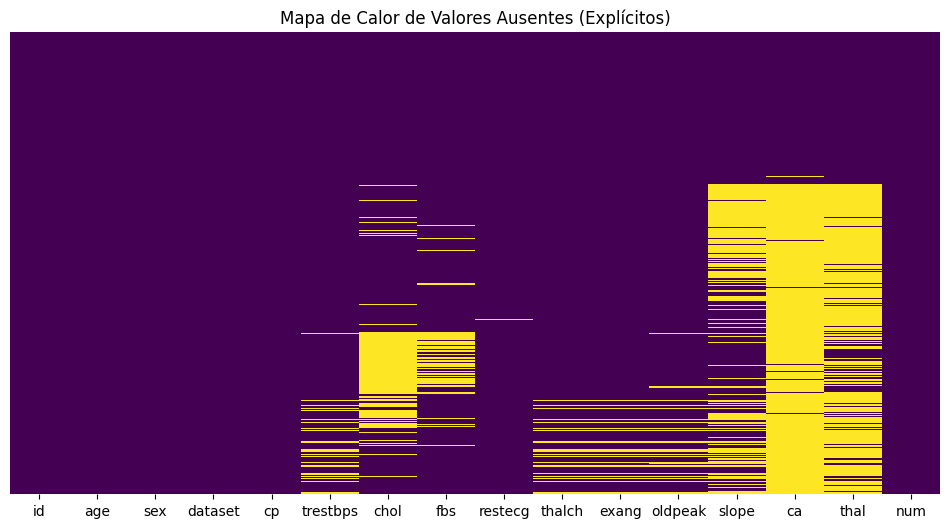

In [89]:
plt.figure(figsize=(12, 6))
sns.heatmap(df.isnull(), yticklabels=False, cbar=False, cmap='viridis')
plt.title('Mapa de Calor de Valores Ausentes (Explícitos)')
plt.show()

In [83]:
from IPython.display import display

def valores_unicos_baixa_cardinalidade(
    df,
    limite=10
):

    for col in df.columns:

        n_unicos = df[col].nunique()

        if n_unicos < limite:

            print("="*50)
            print(f"{col} ({n_unicos} valores)")
            print("="*50)

            print("Valores únicos:")
            print(
                sorted(
                    df[col]
                    .dropna()
                    .unique()
                    .tolist()
                )
            )

            print("\nContagem:")

            display(
                df[col]
                .value_counts()
                .sort_index()
                .to_frame(
                    name="frequencia"
                )
            )

valores_unicos_baixa_cardinalidade(df)

sex (2 valores)
Valores únicos:
['Female', 'Male']

Contagem:


,frequencia
sex,
Female,194
Male,726


dataset (4 valores)
Valores únicos:
['Cleveland', 'Hungary', 'Switzerland', 'VA Long Beach']

Contagem:


,frequencia
dataset,
Cleveland,304
Hungary,293
Switzerland,123
VA Long Beach,200


cp (4 valores)
Valores únicos:
['asymptomatic', 'atypical angina', 'non-anginal', 'typical angina']

Contagem:


...

,frequencia
ca,
0.0,181
1.0,67
2.0,41
3.0,20


thal (3 valores)
Valores únicos:
['fixed defect', 'normal', 'reversable defect']

Contagem:


,frequencia
thal,
fixed defect,46
normal,196
reversable defect,192


num (5 valores)
Valores únicos:
[0, 1, 2, 3, 4]

Contagem:


,frequencia
num,
0,411
1,265
2,109
3,107
4,28


# Análise de Variáveis de Baixa Cardinalidade - Heart Disease UCI

## Resumo Geral
O dataset contém **10 variáveis com baixa cardinalidade** (<10 valores únicos), sendo a maioria variáveis categóricas, binárias ou ordinais. Essas variáveis são relevantes para a modelagem preditiva e para compreensão clínica dos dados.

Além disso, foram identificados padrões relevantes de **desbalanceamento**, **ausência de dados** e possível **heterogeneidade entre centros**, que devem ser considerados antes da modelagem.

---

## Variáveis Categóricas Binárias

### sex (2 valores)
Distribuição de gênero dos pacientes:

- **Female**: 194 pacientes (21.1%)
- **Male**: 726 pacientes (78.9%)

**Observação:** O dataset apresenta predominância masculina (aproximadamente 4:1 em relação a mulheres), o que pode introduzir viés e limitar a generalização do modelo para pacientes do sexo feminino.

---

### fbs (2 valores)
Nível de glicose em jejum >120 mg/dl:

- **False**: 692 pacientes (75.2%) — Nível normal  
- **True**: 138 pacientes (24.8%) — Nível elevado  

**Observação:** A maioria dos pacientes apresenta glicemia em jejum normal.

---

### exang (2 valores)
Angina induzida por exercício:

- **False**: 528 pacientes (57.4%) — Sem angina induzida  
- **True**: 337 pacientes (42.6%) — Com angina induzida  

**Observação:** Distribuição relativamente equilibrada entre pacientes com e sem angina induzida.

---

## Variáveis Categóricas Nominais

### dataset (4 valores)
Origem geográfica dos dados:

- **Cleveland**: 304 pacientes (33.0%)  
- **Hungary**: 293 pacientes (31.8%)  
- **Switzerland**: 123 pacientes (13.4%)  
- **VA Long Beach**: 200 pacientes (21.7%)

**Observação:** Os dados foram coletados em quatro centros distintos. Isso pode introduzir efeito de centro e heterogeneidade populacional.

---

### cp (4 valores)
Tipo de dor no peito:

- **asymptomatic**: 496 pacientes (53.9%)  
- **atypical angina**: 174 pacientes (18.9%)  
- **non-anginal**: 204 pacientes (22.2%)  
- **typical angina**: 46 pacientes (5.0%)

**Observação:** A categoria assintomática predomina. Angina típica é rara.

---

### restecg (3 valores)
Resultados do eletrocardiograma em repouso:

- **normal**: 551 pacientes (59.9%)  
- **lv hypertrophy**: 188 pacientes (20.4%)  
- **st-t abnormality**: 179 pacientes (19.5%)

**Observação:** A maioria apresenta ECG normal, mas aproximadamente 40% possui alguma anormalidade.

---

### slope (3 valores)
Inclinação do segmento ST:

- **flat**: 345 pacientes (37.5%)  
- **upsloping**: 203 pacientes (22.1%)  
- **downsloping**: 63 pacientes (6.8%)

**Observação:** Inclinação plana é a mais frequente.

**Alerta:** 309 valores ausentes (33.6%).

---

## Variáveis Ordinais/Clínicas

### ca (4 valores)
Número de vasos principais com estenose:

- **0.0**: 181 pacientes (19.7%)  
- **1.0**: 67 pacientes (7.3%)  
- **2.0**: 41 pacientes (4.5%)  
- **3.0**: 20 pacientes (2.2%)

**Observação:** A distribuição concentra-se em pacientes sem vasos com estenose detectável.

**Alerta:** 611 valores ausentes (66.4%).

---

### thal (3 valores)
Tipo de defeito talassêmico:

- **normal**: 196 pacientes (21.3%)  
- **fixed defect**: 46 pacientes (5.0%)  
- **reversable defect**: 192 pacientes (20.9%)

**Observação:** Há distribuição relativamente equilibrada entre normal e defeito reversível.

**Alerta:** 486 valores ausentes (52.8%).

---

## Variável-Alvo

### num (5 valores)
Presença e severidade de doença cardíaca:

- **0**: 411 pacientes (44.7%) — Sem doença  
- **1**: 265 pacientes (28.8%) — Doença leve  
- **2**: 109 pacientes (11.8%) — Doença moderada  
- **3**: 107 pacientes (11.6%) — Doença severa  
- **4**: 28 pacientes (3.0%) — Doença muito severa

### Interpretação
A variável possui **natureza ordinal**, com:

```text
0 < 1 < 2 < 3 < 4
```

Portanto, além de classificação multiclasse convencional, existe possibilidade de modelagem ordinal.

---

### Balanceamento do alvo

### Formulação multiclasse
Existe desbalanceamento, especialmente na classe 4 (apenas 3%).

---

### Formulação binária (presença vs ausência)
Agrupando:

- Sem doença (`num = 0`): 411 casos  
- Com doença (`num > 0`): 509 casos

A distribuição torna-se relativamente equilibrada:

- 44.7% vs 55.3%

**Observação:** Para classificação binária, o desbalanceamento deixa de ser uma preocupação relevante.

---

## Ausência de Dados

Foi identificado padrão importante de valores ausentes em:

| Variável | Missing |
|--------|---------|
| slope | 33.6% |
| thal | 52.8% |
| ca | 66.4% |

### Observação metodológica
Os padrões observados sugerem que os dados faltantes podem **não ser completamente aleatórios (MCAR)**, exigindo cautela em estratégias simples de imputação.

Essas ausências podem estar associadas:
- ao centro de origem (`dataset`)
- à gravidade da doença (`num`)
- à não realização de exames específicos

---

## Principais Pontos de Atenção

- Predominância masculina pode gerar viés.
- `ca` e `thal` apresentam altíssimo percentual de ausência.
- A variável-alvo é ordinal.
- O problema pode ser tratado como binário ou multiclasse.
- Há possível efeito de centro (`dataset`).

---

## Recomendações

1. Avaliar o problema tanto como:
   - classificação binária (presença/ausência)
   - classificação ordinal (graus de severidade)

2. Investigar estratégias para `ca`, `thal` e `slope`, comparando:
   - exclusão  
   - imputação  
   - tratamento explícito da ausência

3. Verificar se os dados faltantes estão associados à origem dos centros ou à gravidade da doença.

4. Testar associação entre variáveis categóricas e o alvo (ex.: teste Qui-quadrado).

5. Avaliar possível efeito de centro (`dataset`) e viés por sexo.

6. Caso seja utilizada formulação multiclasse, considerar tratamento das classes raras.

---

## Nota
Percentuais calculados em relação ao total do dataset (n = 920).

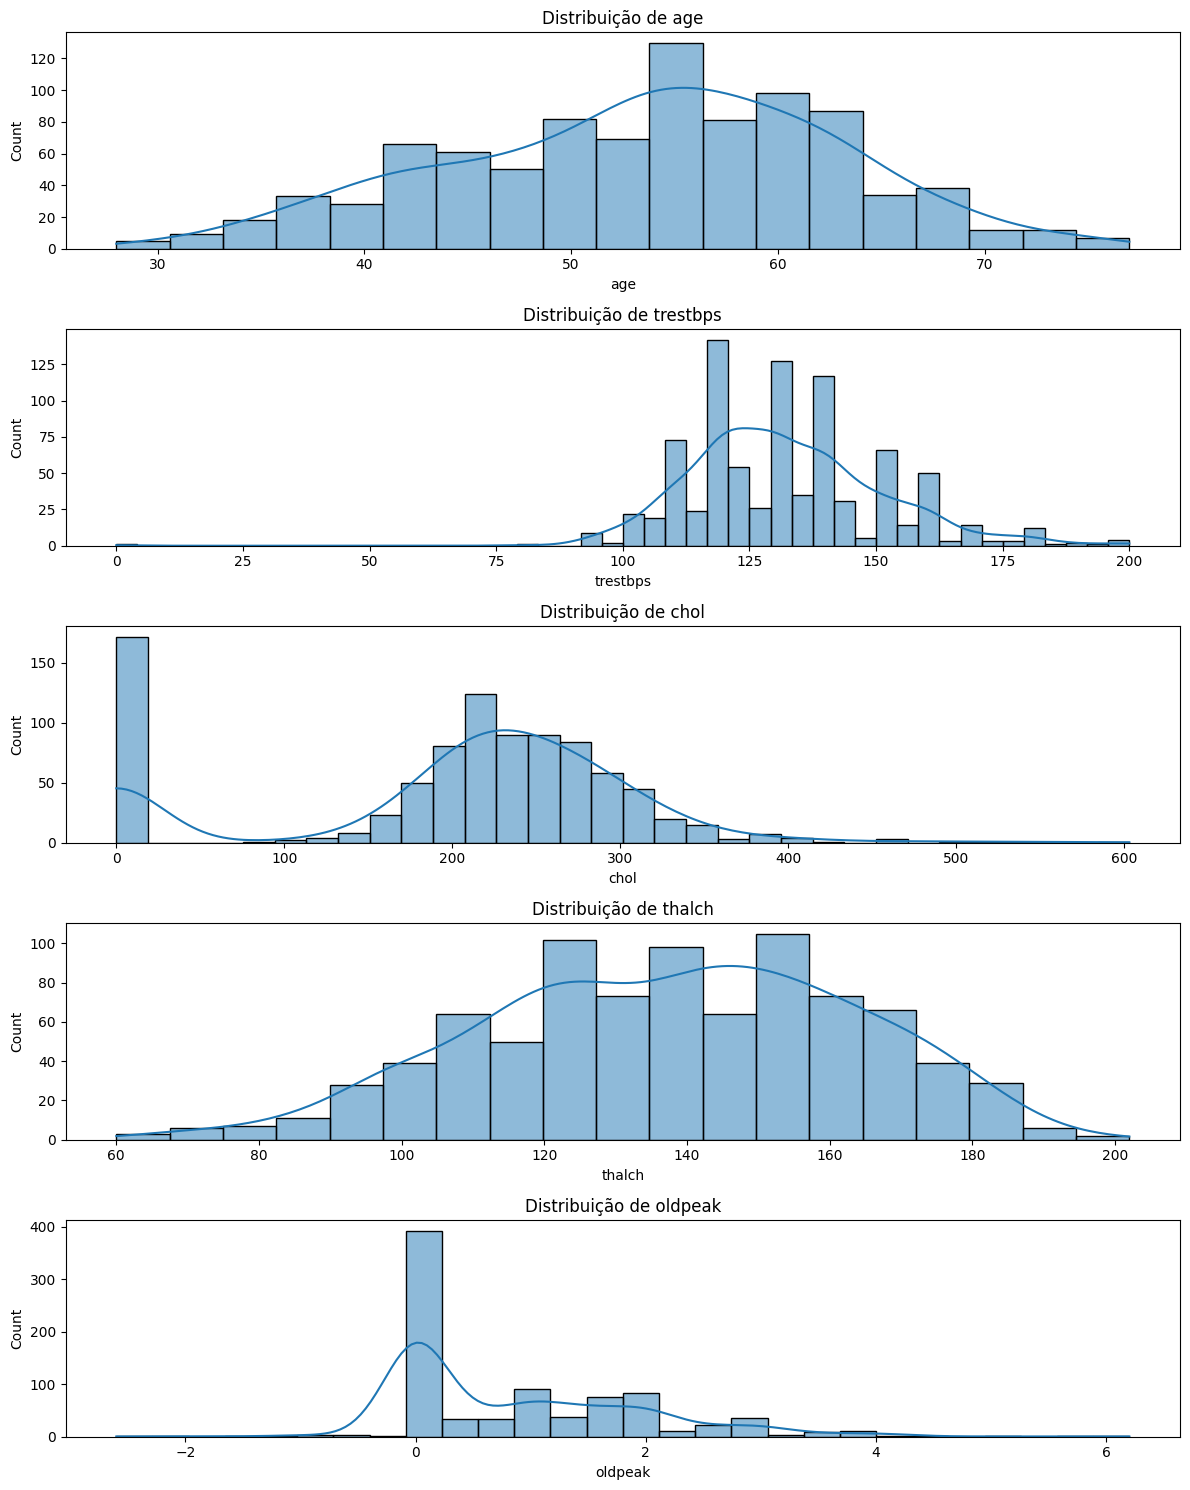

In [62]:
num_cols = [
    'age',
    'trestbps',
    'chol',
    'thalch',
    'oldpeak'
]

fig, axes = plt.subplots(5, 1, figsize=(12, 15))

for idx, col in enumerate(num_cols):
    sns.histplot(
        df[col].dropna(),
        kde=True,
        ax=axes[idx]
    )
    axes[idx].set_title(f'Distribuição de {col}', fontsize=12)

plt.tight_layout()
plt.show()

In [85]:
df[df["trestbps"] == 0]

,id,age,sex,dataset,cp,trestbps,chol,fbs,restecg,thalch,exang,oldpeak,slope,ca,thal,num
753,754,55,Male,VA Long Beach,non-anginal,0.0,0.0,False,normal,155.0,False,1.5,flat,NaN,NaN,3


In [86]:
df["chol"] = df["chol"].replace(
    0,
    np.nan
)

df["trestbps"] = df["trestbps"].replace(
    0,
    np.nan
)

df['trestbps'].count()

np.int64(860)

In [87]:
from scipy.stats import shapiro
from scipy.stats import skew
from scipy.stats import kurtosis
from scipy.stats import normaltest
from IPython.display import display

num_cols = [
    'age',
    'trestbps',
    'chol',
    'thalch',
    'oldpeak'
]

def analisar_normalidade(df, cols):
    """
    Analisa a normalidade das colunas numéricas usando testes estatísticos.
    Exibe os resultados em uma tabela para evitar truncamento.
    """
    print("="*70)
    print("ANÁLISE DE NORMALIDADE")
    print("="*70)
    
    resultados = []
    
    for col in cols:
        dados = df[col].dropna()
        
        if len(dados) < 3:
            continue
        
        # Shapiro (usa amostra se muito grande)
        amostra = dados.sample(min(5000, len(dados)), random_state=42)
        _, p_shapiro = shapiro(amostra)
        
        # D'Agostino
        _, p_normal = normaltest(dados)
        
        assimetria = skew(dados)
        curt = kurtosis(dados)
        
        # Interpretações
        shapiro_interpret = "Aproximadamente normal" if p_shapiro > 0.05 else "Rejeita normalidade"
        assimetria_interpret = (
            "Baixa" if abs(assimetria) < 0.5 
            else "Moderada" if abs(assimetria) < 1 
            else "Forte"
        )
        
        resultados.append({
            'Coluna': col,
            'Shapiro p-value': f"{p_shapiro:.6f}",
            'D\'Agostino p-value': f"{p_normal:.6f}",
            'Skewness': f"{assimetria:.4f}",
            'Kurtosis': f"{curt:.4f}",
            'Shapiro Interpretação': shapiro_interpret,
            'Assimetria Interpretação': assimetria_interpret
        })
    
    # Criar DataFrame e exibir com display
    df_resultados = pd.DataFrame(resultados)
    display(df_resultados)

# Usar a função
analisar_normalidade(df, num_cols)

ANÁLISE DE NORMALIDADE


,Coluna,Shapiro p-value,D'Agostino p-value,Skewness,Kurtosis,Shapiro Interpretação,Assimetria Interpretação
0,age,0.000023,0.000808,-0.1957,-0.3874,Rejeita normalidade,Baixa
1,trestbps,0.000000,0.000000,0.6291,0.6199,Rejeita normalidade,Moderada
2,chol,0.000000,0.000000,1.3121,4.7313,Rejeita normalidade,Forte
3,thalch,0.000019,0.000033,-0.2108,-0.4839,Rejeita normalidade,Baixa
4,oldpeak,0.000000,0.000000,1.0396,1.1135,Rejeita normalidade,Forte


# Análise de Normalidade das Variáveis Numéricas

Foram avaliadas as variáveis numéricas contínuas utilizando:

- Teste de Shapiro-Wilk  
- Teste de D’Agostino-Pearson  
- Assimetria (Skewness)  
- Curtose (Kurtosis)  

---

## Resultados

| Variável | Skewness | Kurtosis | Interpretação |
|---------|----------|----------|---------------|
| age | -0.1957 | -0.3874 | Aproximadamente simétrica |
| trestbps | 0.6291 | 0.6199 | Assimetria moderada |
| chol | 1.3121 | 4.7313 | Forte assimetria |
| thalch | -0.2108 | -0.4839 | Aproximadamente simétrica |
| oldpeak | 1.0396 | 1.1135 | Forte assimetria |

---

## Interpretação dos Testes

Os testes de Shapiro-Wilk e D’Agostino rejeitaram a hipótese de normalidade para todas as variáveis (p < 0.05).

Considerando o tamanho da amostra (n = 920), essa rejeição é esperada mesmo para distribuições próximas da normal. Por isso, a interpretação foi baseada principalmente na assimetria e curtose.

---

## Análise por Variável

### Aproximadamente simétricas
- **age**
- **thalch**

Apresentam baixa assimetria e curtose próxima de zero, indicando distribuições próximas de simétricas.

---

### Assimetria moderada
- **trestbps**

Apresenta leve concentração à direita, com alguma distorção na distribuição.

---

### Forte assimetria
- **chol**
- **oldpeak**

Ambas apresentam cauda longa à direita e maior concentração de valores baixos.

---

## Observação

De forma geral, as variáveis não seguem normalidade estrita, com diferentes níveis de assimetria.  
Esse comportamento deve ser considerado na escolha de métodos estatísticos e na análise exploratória.

In [88]:
resumo=[]

for col in num_cols:

    dados = df[col].dropna()

    resumo.append({
        "Variavel":col,
        "Media":dados.mean(),
        "Mediana":dados.median(),
        "Desvio":dados.std(),
        "Min":dados.min(),
        "Q1":dados.quantile(.25),
        "Q3":dados.quantile(.75),
        "Max":dados.max(),
        "CV":dados.std()/dados.mean()
    })

pd.DataFrame(resumo)

,Variavel,Media,Mediana,Desvio,Min,Q1,Q3,Max,CV
0,age,53.510870,54.0,9.424685,28.0,47.0,60.00,77.0,0.176127
1,trestbps,132.286047,130.0,18.536175,80.0,120.0,140.00,200.0,0.140122
2,chol,246.832869,239.5,58.527062,85.0,210.0,276.75,603.0,0.237112
3,thalch,137.545665,140.0,25.926276,60.0,120.0,157.00,202.0,0.188492
4,oldpeak,0.878788,0.5,1.091226,-2.6,0.0,1.50,6.2,1.241740


# Análise Descritiva das Variáveis Numéricas

Foi realizada análise descritiva considerando média, mediana, desvio padrão, quartis e coeficiente de variação (CV), com foco em dispersão, assimetria e presença de valores extremos.

---

## Principais Observações

### age
- Média ≈ mediana → distribuição simétrica  
- Baixa variabilidade (CV ≈ 17%)  
- Faixa de valores plausível (28–77)  

---

### trestbps
- Média próxima da mediana → distribuição relativamente estável  
- Presença de valores extremos (até 200)  
- Valor mínimo igual a 0 é inconsistente (possível missing implícito)  

---

### chol
- Média maior que a mediana → assimetria à direita  
- Valores elevados (até 603) indicam outliers  
- Variabilidade moderada (CV ≈ 24%)  
- Zeros previamente tratados como ausentes  

---

### thalch
- Distribuição aproximadamente simétrica  
- Variabilidade moderada (CV ≈ 19%)  
- Valores dentro de faixa plausível (60–202)  

---

### oldpeak
- Forte assimetria à direita  
- Alta dispersão (CV > 100%)  
- Concentração em zero e presença de valores extremos  
- Valor mínimo negativo (-2.6) requer verificação  

---

## Síntese

- **Mais estáveis:** `age`, `thalch`  
- **Com extremos/outliers:** `trestbps`, `chol`  
- **Maior variabilidade:** `oldpeak`  

---

## Conclusão

As variáveis apresentam diferentes níveis de dispersão e assimetria.  
`age` e `thalch` mostram comportamento mais regular, enquanto `chol` e `oldpeak` concentram maior variabilidade e valores extremos.

## Distribuição da Variável Alvo (num)

A variável 'num' indica a presença de doença cardíaca (0 = ausência, 1-4 = presença em diferentes níveis).

C:\Users\renna\AppData\Local\Temp\ipykernel_19076\321448088.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='num', data=df, palette='viridis')


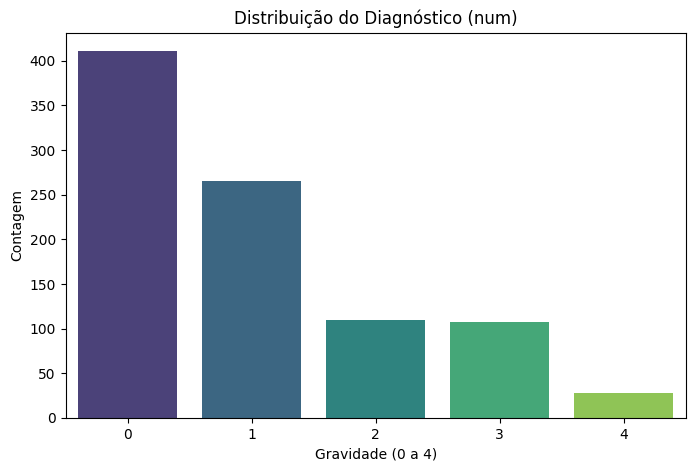

In [90]:
plt.figure(figsize=(8, 5))
sns.countplot(x='num', data=df, palette='viridis')
plt.title('Distribuição do Diagnóstico (num)')
plt.xlabel('Gravidade (0 a 4)')
plt.ylabel('Contagem')
plt.show()

Pode apresentar problemas para análise multiclasse devido desbalanceamento (classe 4), porém é possível agrupar para análise binária ou então multiclasse agrupando 2-3-4

## Correlação entre Vars Numéricas

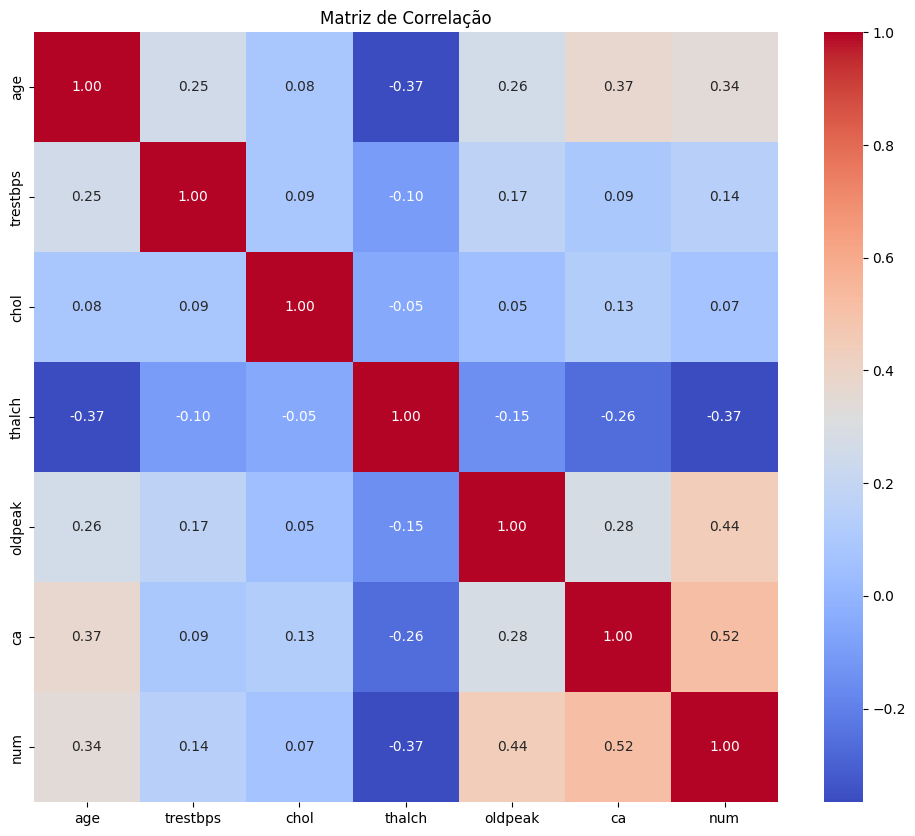

In [92]:
df_sem_id = df.drop(columns=['id'])
plt.figure(figsize=(12, 10))
numeric_cols = df_sem_id.select_dtypes(include=[np.number]).columns
corr_matrix = df_sem_id[numeric_cols].corr()
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Matriz de Correlação')
plt.show()

## Buscando padrões entre Variáveis

C:\Users\renna\AppData\Local\Temp\ipykernel_19076\3656026598.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


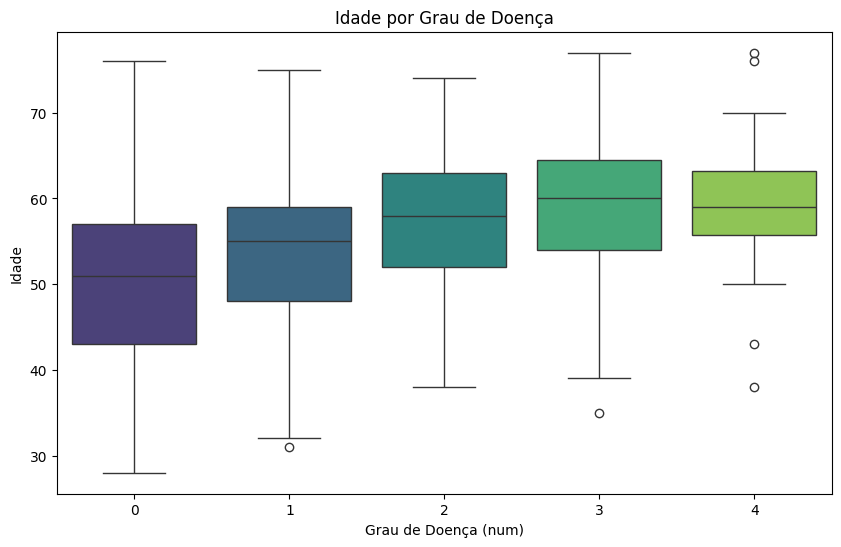

In [96]:
plt.figure(figsize=(10,6))

sns.boxplot(
    data=df,
    x='num',
    y='age',
    palette='viridis'
)

plt.title('Idade por Grau de Doença')
plt.xlabel('Grau de Doença (num)')
plt.ylabel('Idade')

plt.show()

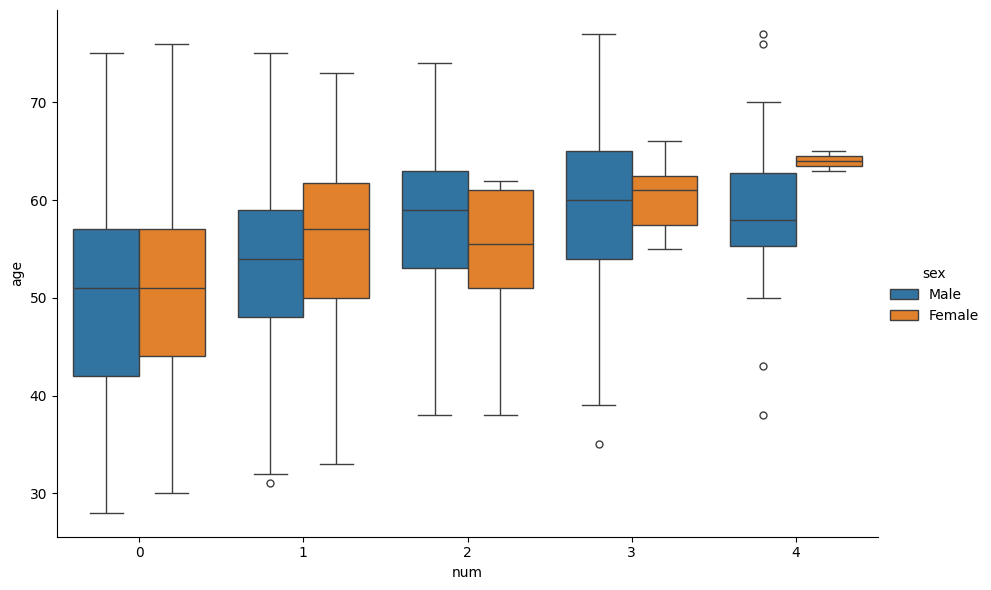

In [97]:
sns.catplot(
    data=df,
    x='num',
    y='age',
    hue='sex',
    kind='box',
    height=6,
    aspect=1.5
)

## Idade por Grau de Doença e Sexo

Foi analisada a distribuição da idade em função do grau de doença (`num`), considerando também a separação por sexo.

---

## Principais Observações

- Há uma **tendência de aumento da idade mediana** conforme o grau de doença (`num`) aumenta.  
  - Indica associação positiva entre idade e gravidade da condição.

- A variabilidade da idade se mantém relativamente consistente entre as classes, com presença de outliers em praticamente todos os níveis.

---

## Diferenças por Sexo

- Em níveis mais baixos de doença (`num` 0–2), **homens e mulheres apresentam distribuições semelhantes**, com leve variação nas medianas.

- Nos níveis mais altos (`num` 3–4), observa-se:
  - **menor quantidade de observações femininas**  
  - maior concentração de idades em faixas mais altas  

---

## Outliers

- Há presença de outliers em diversas classes, incluindo:
  - idades mais baixas em níveis altos de doença  
  - idades mais elevadas em níveis intermediários  

Esses pontos indicam variabilidade individual e não necessariamente inconsistência dos dados.

---

## Síntese

A análise sugere que:

- A idade está associada à gravidade da doença cardíaca  
- A distribuição por sexo é relativamente equilibrada nos níveis iniciais, mas menos representativa nos níveis mais altos  
- Existe dispersão relevante dentro de cada classe, indicando heterogeneidade entre os pacientes

In [98]:
from scipy.stats import spearmanr

corr, p_value = spearmanr(df['age'], df['num'])

print(f"Spearman correlation: {corr:.4f}")
print(f"p-value: {p_value:.4e}")

Spearman correlation: 0.3472
p-value: 1.8723e-27


In [ ]:
from scipy.stats import kruskal
import scikit_posthocs as sp

grupos = [df[df['num'] == i]['age'].dropna() for i in sorted(df['num'].unique())]

stat, p_value = kruskal(*grupos)

print(f"Kruskal-Wallis H-statistic: {stat:.4f}")
print(f"p-value: {p_value:.4e}")

if p_value < 0.05:
    print("Diferença significativa entre os grupos de idade por grau de doença.")
    

    posthoc = sp.posthoc_dunn(
        df,
        val_col='age',
        group_col='num',
        p_adjust='bonferroni'
    )

    print(posthoc)

Kruskal-Wallis H-statistic: 116.0464
p-value: 3.7314e-24
